In this section we simulate the card shuffling scheme mentioned in theorem 2.8 of the paper.

In [36]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

In [37]:
# constants
N = 500

To simulate the shuffling, we define $Y_i$ as the position of a given card at time $i$. For the computation of $Y_i$ we use the recursive formula given in the proof of the theorem on page $31$ of the paper 
\begin{equation}
Y_{i+1} = Y_i + \xi_i (1_{\{Z_i=1\}} - 1_{\{Z_i=0\}}) + 1_{\{Z_i=0\}} - 1_{\{Z_i=1\}},
\end{equation}

where $Y_0$, being drawn from the stationary distribution, is sampled from $\mathcal{U}[1, \dots, N]$. We define $\xi_0,\dots \xi_i \sim \text{Ber}(1/2)$ iid.
To obtain the 



In [38]:
def shuffle_cards_difference(card_position):
    # probability that says if we do nothing or shuffle the cards
    generated_prob = np.random.random()

    # 1/3 chance to do nothing
    if generated_prob <= 1/3:
        return 0
    
    # 2/3 chances to use the Q-chain
    xi = np.round(np.random.random()) # bernouilli(1/2)
    Z = card_position % N # in case we get to the bottom we do modulo
    indicator_Z1 = 1 if Z == 1 else 0
    indicator_Z0 = 0 if Z == 1 else 1
    
    W = indicator_Z1 - indicator_Z0
    return xi*(1 + W) - W 

We use the equation (3.30) of the paper on page 31 to recursively compute $Y_n$

\begin{equation}
Y_n = Y_0 + \sum\limits_{i=0}^{n-1}(\xi_i(1+W_i) - W_i)
\end{equation}
NOTE: The position is $Y_n$ modN, not $Y_n$. $\newline$ 
The function $f$ we use for $\Delta_n$ is defined in page 32 as 
\begin{equation}
f(x) := \cos(\frac{2\pi (x(1)-x(2))}{N})
\end{equation}

In [ ]:
def stationary_average(): # verify outputs...
    # the stationary distribution of X is the uniform one.
    sum_possibilities = 0
    for X_1 in range(N):
        for X_2 in range(N):
            if X_1 == X_2:
                continue
            sum_possibilities += np.cos(2*np.pi*(X_1 - X_2)/N)
    return 1/(N**2 - N) * sum_possibilities

def compute_delta(number_deltas, iteration_count):
    all_deltas = np.zeros((number_deltas, iteration_count))
    mu_f = stationary_average()

    for j in range(number_deltas):
        curr_x_1 = np.random.randint(0, N) # including or excluding N?
        curr_x_2 = np.random.randint(0, N)
        f_sum = 0
        for i in range(iteration_count):
            curr_x_1 = (curr_x_1 + shuffle_cards_difference(curr_x_1)) % N
            curr_x_2 = (curr_x_2 + shuffle_cards_difference(curr_x_2)) % N
            f = np.cos(2*np.pi*(curr_x_1 - curr_x_2)/N)
            f_sum += f 
            f_empirical_mean = f/(i+1)
            all_deltas[j, i] = (f_empirical_mean - mu_f)**2
    delta_n = np.sqrt(np.mean(all_deltas, axis=0))
    return delta_n



In [40]:
iteration_count = 100
number_deltas = 10
delta_1000 = compute_delta(number_deltas, iteration_count)

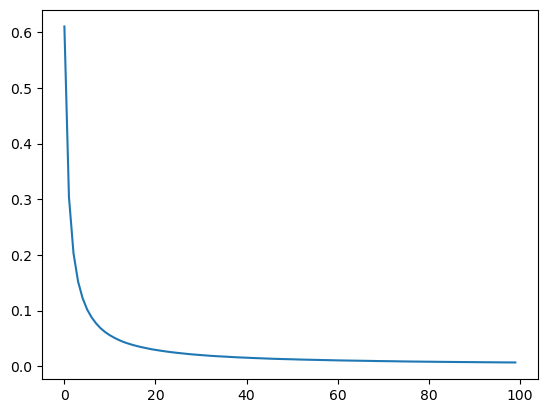

In [41]:
plt.plot(range(iteration_count), delta_1000)